# JAXTPC Simulation

GPU-accelerated liquid argon TPC detector simulation.

**Workflow:**
1. Load detector configuration and particle segment data
2. Run simulation (recombination, drift, diffusion, wire response)
3. Convert output to dense or sparse format
4. Visualize: detector response, truth hits, track labels

**Settings:** Toggle flags in the configuration cell.

## Setup and Configuration

In [22]:
# =============================================================================
# CONFIGURATION
# =============================================================================

CONFIG_PATH = "config/cubic_wireplane_config.yaml"
DATA_PATH = "muon.h5"
EVENT_IDX = 0

# Accumulation mode
USE_BUCKETED = True
MAX_ACTIVE_BUCKETS = 1000

# Post-processing inside JIT
INCLUDE_NOISE = False
INCLUDE_ELECTRONICS = False
INCLUDE_DIGITIZATION = True
INCLUDE_ELECTRIC_DISTORTIONS = False

# Track labeling
INCLUDE_TRACK_HITS = True

# Threshold for sparse visualization (electrons)
THRESHOLD_ENC = 1200

# Performance knobs
TOTAL_PAD = 200_000          # Padded array size per side (sets JIT shape)
RESPONSE_CHUNK_SIZE = 50_000 # Deposits per fori_loop iteration
MAX_KEYS = 2_000_000         # Max unique hits for track labeling (only when enabled)

print("Configuration:")
print(f"  Config: {CONFIG_PATH}")
print(f"  Data: {DATA_PATH}, Event: {EVENT_IDX}")
print(f"  Bucketed: {USE_BUCKETED}")
print(f"  Noise: {'ON' if INCLUDE_NOISE else 'OFF'}")
print(f"  Electronics: {'ON' if INCLUDE_ELECTRONICS else 'OFF'}")
print(f"  Digitization: {'ON' if INCLUDE_DIGITIZATION else 'OFF'}")
print(f"  Track labeling: {'ON' if INCLUDE_TRACK_HITS else 'OFF'}")
print(f"  Threshold: {THRESHOLD_ENC} e-")
print(f"  total_pad: {TOTAL_PAD:,}, chunk: {RESPONSE_CHUNK_SIZE:,}, max_keys: {MAX_KEYS:,}")

Configuration:
  Config: config/cubic_wireplane_config.yaml
  Data: muon.h5, Event: 0
  Bucketed: True
  Noise: OFF
  Electronics: OFF
  Digitization: ON
  Track labeling: ON
  Threshold: 1200 e-
  total_pad: 200,000, chunk: 50,000, max_keys: 2,000,000


In [23]:
# =============================================================================
# IMPORTS
# =============================================================================

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import gc

from tools.simulation import DetectorSimulator
from tools.geometry import generate_detector
from tools.loader import load_event
from tools.config import create_track_hits_config
from tools.output import to_dense, to_sparse

from tools.visualization import (
    visualize_wire_signals,
    visualize_diffused_charge,
    visualize_track_labels,
    get_top_tracks_by_charge,
)

os.makedirs("plots", exist_ok=True)

print(f"JAX version: {jax.__version__}")
print(f"JAX devices: {jax.devices()}")

JAX version: 0.9.2
JAX devices: [CpuDevice(id=0)]


## Load Data

In [24]:
# =============================================================================
# LOAD DATA
# =============================================================================

detector_config = generate_detector(CONFIG_PATH)

# Create simulator first (needed for config to build deposits)
jax.clear_caches()
gc.collect()

track_config = create_track_hits_config(max_keys=MAX_KEYS) if INCLUDE_TRACK_HITS else None

simulator = DetectorSimulator(
    detector_config,
    use_bucketed=USE_BUCKETED,
    max_active_buckets=MAX_ACTIVE_BUCKETS,
    include_noise=INCLUDE_NOISE,
    include_electronics=INCLUDE_ELECTRONICS,
    include_track_hits=INCLUDE_TRACK_HITS,
    include_electric_dist=INCLUDE_ELECTRIC_DISTORTIONS,
    include_digitize=INCLUDE_DIGITIZATION,
    total_pad=TOTAL_PAD,
    response_chunk_size=RESPONSE_CHUNK_SIZE,
    track_config=track_config,
)

cfg = simulator.config

print(f"\nLoading event {EVENT_IDX} from {DATA_PATH}...")
deposits = load_event(DATA_PATH, cfg, event_idx=EVENT_IDX)

n_volumes = len(deposits.volumes)
n_total = sum(v.n_actual for v in deposits.volumes)
print(f"Loaded {n_total:,} deposits across {n_volumes} volumes")
for v in range(n_volumes):
    vol = deposits.volumes[v]
    print(f"  Volume {v}: {vol.n_actual:,} deposits")

--- Creating DetectorSimulator ---
   Extracting parameters...
   Loading response kernels...
   Space charge effects: DISABLED
   Recombination model: emb
   Config: total_pad=200,000, response_chunk=50,000, num_s=16, K_wire=2, K_time=6
   Using BUCKETED accumulation (max_buckets=1000)
   Digitization: ENABLED (12-bit)
   Track labeling: ENABLED
   Readout: wire
   Volumes: 2 (iterate=scan)
--- DetectorSimulator Ready ---

Loading event 0 from muon.h5...
Loaded 5,335 deposits across 2 volumes
  Volume 0: 5,335 deposits
  Volume 1: 0 deposits


## Create Simulator and Run

In [25]:
# =============================================================================
# WARM UP + RUN
# =============================================================================

print("Warming up JIT...")
simulator.warm_up()
print("Done.")

Warming up JIT...
Triggering JIT compilation...
JIT compilation finished (total_pad=200,000, iterate=scan).
Done.


In [26]:
# =============================================================================
# RUN SIMULATION
# =============================================================================

print("Running simulation...")
t0 = time.time()

response_signals, track_hits_raw, deposits = simulator.process_event(
    deposits, key=jax.random.PRNGKey(42))

# Wait for GPU
for val in response_signals.values():
    if isinstance(val, tuple):
        jax.block_until_ready(val[0])
    else:
        jax.block_until_ready(val)

elapsed = time.time() - t0
print(f"Simulation: {elapsed:.2f}s ({n_total / elapsed:,.0f} segments/sec)")
print(f"Output format: {cfg.output_format}")

Running simulation...
Simulation: 8.20s (651 segments/sec)
Output format: bucketed


## Convert Output

Convert simulation output (dense, bucketed, or wire-sparse) to sparse format:
- **Sparse**: `{(vol, plane): {'wire': (N,), 'time': (N,), 'values': (N,)}}` — for scatter plots and storage

In [27]:
# =============================================================================
# CONVERT TO SPARSE
# =============================================================================

threshold_adc = THRESHOLD_ENC / cfg.electrons_per_adc
t0 = time.time()
sparse_signals = to_sparse(response_signals, cfg, threshold_adc=threshold_adc)
print(f"to_sparse ({THRESHOLD_ENC} e-): {time.time() - t0:.2f}s")

# Statistics
print(f"\nSparse output (threshold={THRESHOLD_ENC} e-):")
print(f"{'Plane':<16} {'Pixels':>10} {'Sparsity':>10}")
print("-" * 40)
for (vi, pi), data in sorted(sparse_signals.items()):
    n_pix = len(data['values'])
    total = cfg.volumes[vi].num_wires[pi] * cfg.num_time_steps
    sparsity = (1 - n_pix / total) * 100
    ptype = cfg.plane_names[vi][pi]
    print(f"  Vol {vi} {ptype:<5} {n_pix:>10,} {sparsity:>9.1f}%")

to_sparse (1200 e-): 0.23s

Sparse output (threshold=1200 e-):
Plane                Pixels   Sparsity
----------------------------------------
  Vol 0 U          8,210      99.8%
  Vol 0 V          2,467     100.0%
  Vol 0 Y          1,431     100.0%
  Vol 1 U              0     100.0%
  Vol 1 V              0     100.0%
  Vol 1 Y              0     100.0%


## Finalize Track Hits

In [28]:
# =============================================================================
# FINALIZE TRACK HITS
# =============================================================================

if INCLUDE_TRACK_HITS:
    track_hits = simulator.finalize_track_hits(track_hits_raw)

    total_hits = 0
    print("Track hits per plane:")
    print(f"{'Plane':<16} {'Hits':>10} {'Labeled':>10}")
    print("-" * 40)
    for (vi, pi), data in sorted(track_hits.items()):
        nh = int(data['num_hits'])
        nl = int(data['num_labeled'])
        total_hits += nh
        ptype = cfg.plane_names[vi][pi]
        print(f"  Vol {vi} {ptype:<5} {nh:>10,} {nl:>10,}")
    print("-" * 40)
    print(f"  {'Total':<14} {total_hits:>10,}")
else:
    track_hits = None
    print("Track labeling disabled.")

Track hits per plane:
Plane                  Hits    Labeled
----------------------------------------
  Vol 0 U          3,546      2,668
  Vol 0 V          3,332      2,493
  Vol 0 Y          2,778      1,913
  Vol 1 U              0          0
  Vol 1 V              0          0
  Vol 1 Y              0          0
----------------------------------------
  Total               9,656


## Visualization

1. **Response signals** (dense): full detector view with imshow
2. **Truth hits**: diffused charge colored by magnitude
3. **Track labels**: pixels colored by dominant track ID

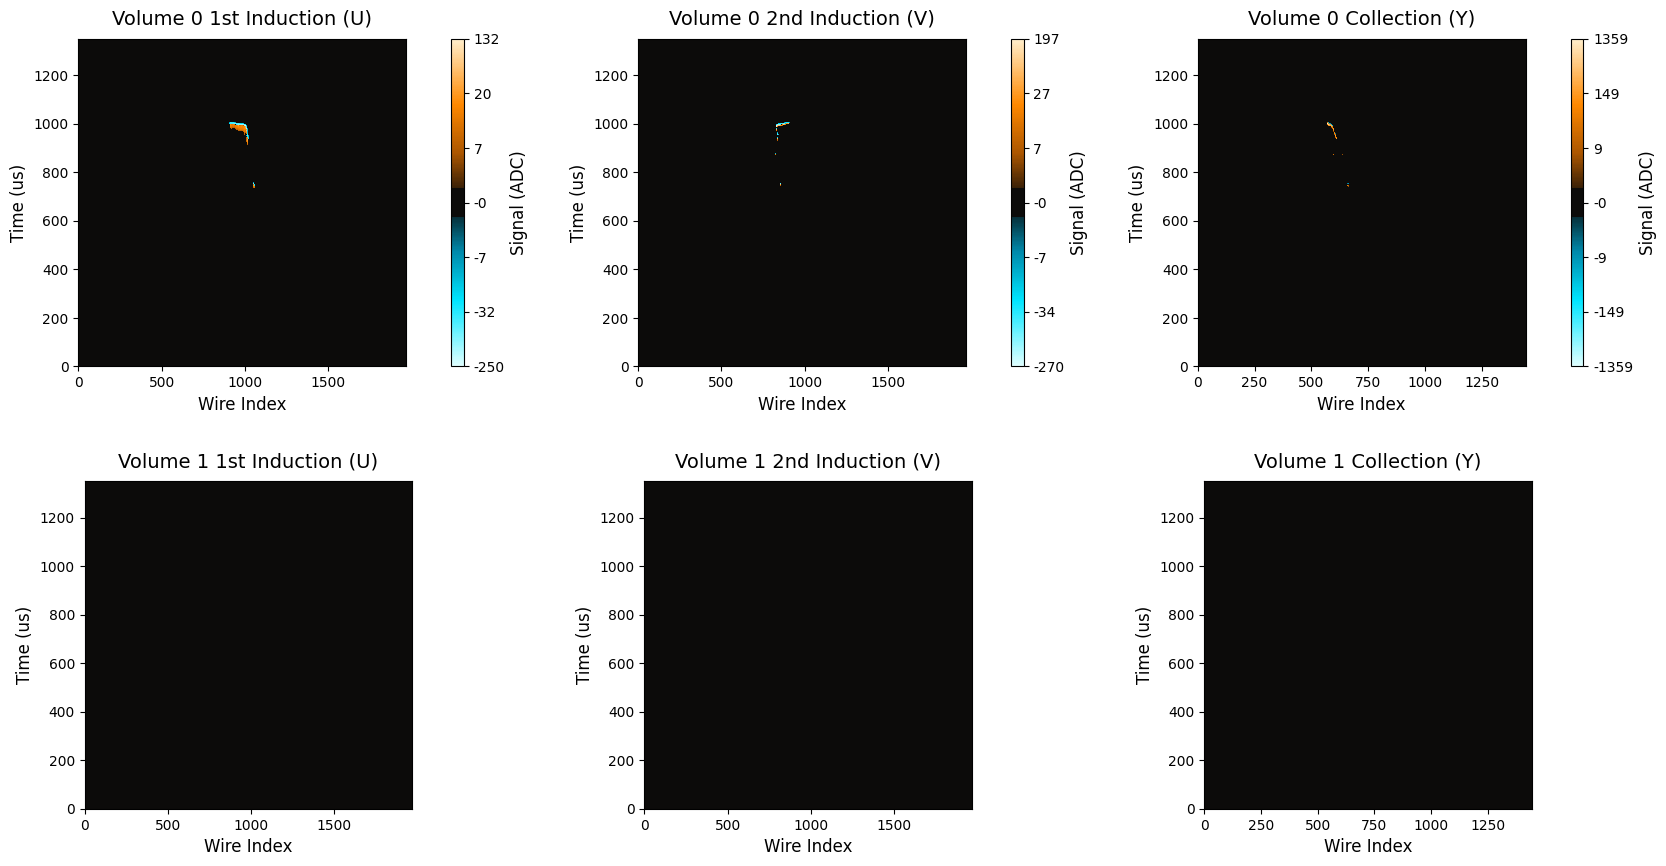

In [29]:
# =============================================================================
# VISUALIZE RESPONSE SIGNALS (SPARSE)
# =============================================================================

fig = visualize_wire_signals(
    sparse_signals, cfg,
    threshold_enc=THRESHOLD_ENC, gamma=0.2,
    sparse=True,
    )
fig.savefig("plots/response_new.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [30]:
# =============================================================================
# PLOTLY: RESPONSE SIGNALS (INTERACTIVE)
# =============================================================================
import plotly.graph_objects as go
from plotly.subplots import make_subplots

_keys = sorted(sparse_signals.keys())
_n_rows = cfg.n_volumes
_n_cols = max(cfg.volumes[v].n_planes for v in range(cfg.n_volumes))

_titles = []
for vi in range(_n_rows):
    for pi in range(cfg.volumes[vi].n_planes):
        _titles.append(f"Vol {vi} — {cfg.plane_names[vi][pi]}-plane")

fig_resp_px = make_subplots(
    rows=_n_rows, cols=_n_cols,
    subplot_titles=_titles,
    horizontal_spacing=0.08, vertical_spacing=0.12,
)

for _idx, ((vi, pi), data) in enumerate(sorted(sparse_signals.items())):
    _wire  = np.asarray(data['wire'],   dtype=np.float32)
    _t     = np.asarray(data['time'],   dtype=np.float32) * cfg.time_step_us
    _vals  = np.asarray(data['values'], dtype=np.float32)
    _show_scale = (_idx == 0)

    fig_resp_px.add_trace(go.Scattergl(
        x=_t, y=_wire,
        mode='markers',
        marker=dict(
            color=_vals,
            colorscale='Plasma',
            size=2,
            showscale=_show_scale,
            colorbar=dict(title='ADC', thickness=12) if _show_scale else None,
        ),
        name=f"Vol{vi}/{cfg.plane_names[vi][pi]}",
        hovertemplate="time: %{x:.2f} µs<br>wire: %{y}<br>ADC: %{marker.color:.1f}<extra></extra>",
    ), row=vi + 1, col=pi + 1)

    fig_resp_px.update_xaxes(title_text="Time (µs)", row=vi + 1, col=pi + 1)
    fig_resp_px.update_yaxes(title_text="Wire",       row=vi + 1, col=pi + 1)

fig_resp_px.update_layout(
    title=f"Response Signals — Event {EVENT_IDX}  (threshold={THRESHOLD_ENC} e⁻)",
    height=400 * _n_rows, width=420 * _n_cols,
    plot_bgcolor='#111111', paper_bgcolor='white',
    font=dict(size=11),
    showlegend=False,
)
fig_resp_px.show()


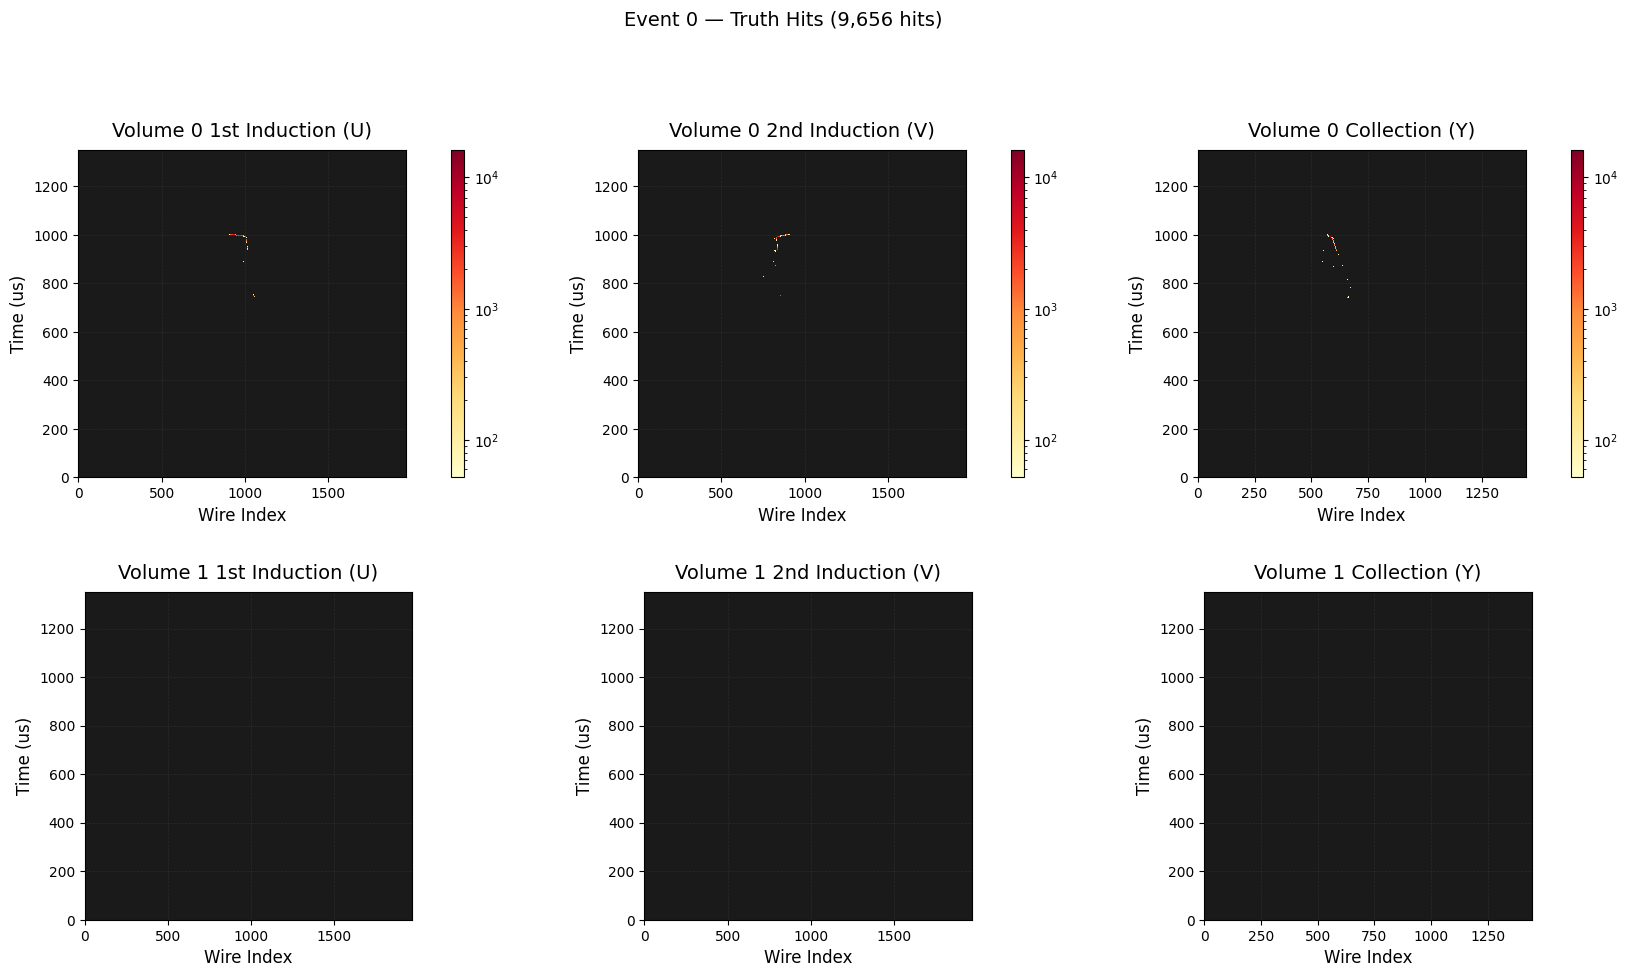

In [31]:
# =============================================================================
# VISUALIZE TRUTH HITS (SPARSE)
# =============================================================================

if INCLUDE_TRACK_HITS:
    # Build sparse truth data from track hits (no densification needed)
    truth_sparse = {}
    for (vi, pi), data in track_hits.items():
        nh = int(data['num_hits'])
        if nh > 0:
            hbt = np.array(data['hits_by_track'][:nh])
            truth_sparse[(vi, pi)] = {
                'wire': hbt[:, 0].astype(np.int32),
                'time': hbt[:, 1].astype(np.int32),
                'values': hbt[:, 2].astype(np.float32),
            }
        else:
            truth_sparse[(vi, pi)] = {
                'wire': np.array([], dtype=np.int32),
                'time': np.array([], dtype=np.int32),
                'values': np.array([], dtype=np.float32),
            }

    fig_truth = visualize_diffused_charge(truth_sparse, cfg,
                                           log_norm=True, threshold=50,
                                           sparse=True)
    fig_truth.suptitle(f'Event {EVENT_IDX} — Truth Hits ({total_hits:,} hits)',
                       fontsize=14, y=1.02)
    fig_truth.savefig("plots/truth_hits_new.png", dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
else:
    print("Track labeling disabled.")

In [32]:
# =============================================================================
# PLOTLY: TRUTH HITS (INTERACTIVE)
# =============================================================================
if INCLUDE_TRACK_HITS:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

    _n_rows = cfg.n_volumes
    _n_cols = max(cfg.volumes[v].n_planes for v in range(cfg.n_volumes))
    _titles = [
        f"Vol {vi} — {cfg.plane_names[vi][pi]}-plane"
        for vi in range(_n_rows)
        for pi in range(cfg.volumes[vi].n_planes)
    ]

    fig_truth_px = make_subplots(
        rows=_n_rows, cols=_n_cols,
        subplot_titles=_titles,
        horizontal_spacing=0.08, vertical_spacing=0.12,
    )

    for _idx, ((vi, pi), data) in enumerate(sorted(truth_sparse.items())):
        _wire = np.asarray(data['wire'],   dtype=np.float32)
        _t    = np.asarray(data['time'],   dtype=np.float32) * cfg.time_step_us
        _vals = np.asarray(data['values'], dtype=np.float32)
        _show_scale = (_idx == 0)

        if len(_wire) > 0:
            _log_vals = np.log10(np.clip(_vals, 1, None))
        else:
            _log_vals = _vals

        fig_truth_px.add_trace(go.Scattergl(
            x=_t, y=_wire,
            mode='markers',
            marker=dict(
                color=_log_vals,
                colorscale='YlOrRd',
                size=2,
                showscale=_show_scale,
                colorbar=dict(title='log₁₀(charge)', thickness=12) if _show_scale else None,
            ),
            name=f"Vol{vi}/{cfg.plane_names[vi][pi]}",
            hovertemplate="time: %{x:.2f} µs<br>wire: %{y}<br>charge: %{marker.color:.2f}<extra></extra>",
        ), row=vi + 1, col=pi + 1)

        fig_truth_px.update_xaxes(title_text="Time (µs)", row=vi + 1, col=pi + 1)
        fig_truth_px.update_yaxes(title_text="Wire",       row=vi + 1, col=pi + 1)

    fig_truth_px.update_layout(
        title=f"Truth Hits — Event {EVENT_IDX}  ({total_hits:,} hits)",
        height=400 * _n_rows, width=420 * _n_cols,
        plot_bgcolor='#1a1a1a', paper_bgcolor='white',
        font=dict(size=11),
        showlegend=False,
    )
    fig_truth_px.show()
else:
    print("Track labeling disabled.")


Top 10 tracks by charge:
   1. Track    0:  6,486,855.5
   2. Track   14:  1,457,897.6
   3. Track   63:    367,426.3
   4. Track   22:    310,105.8
   5. Track   17:    144,416.6
   6. Track   62:     60,672.9
   7. Track   79:     30,503.9
   8. Track   68:     23,902.4
   9. Track   69:      9,540.6
  10. Track   70:      7,797.4


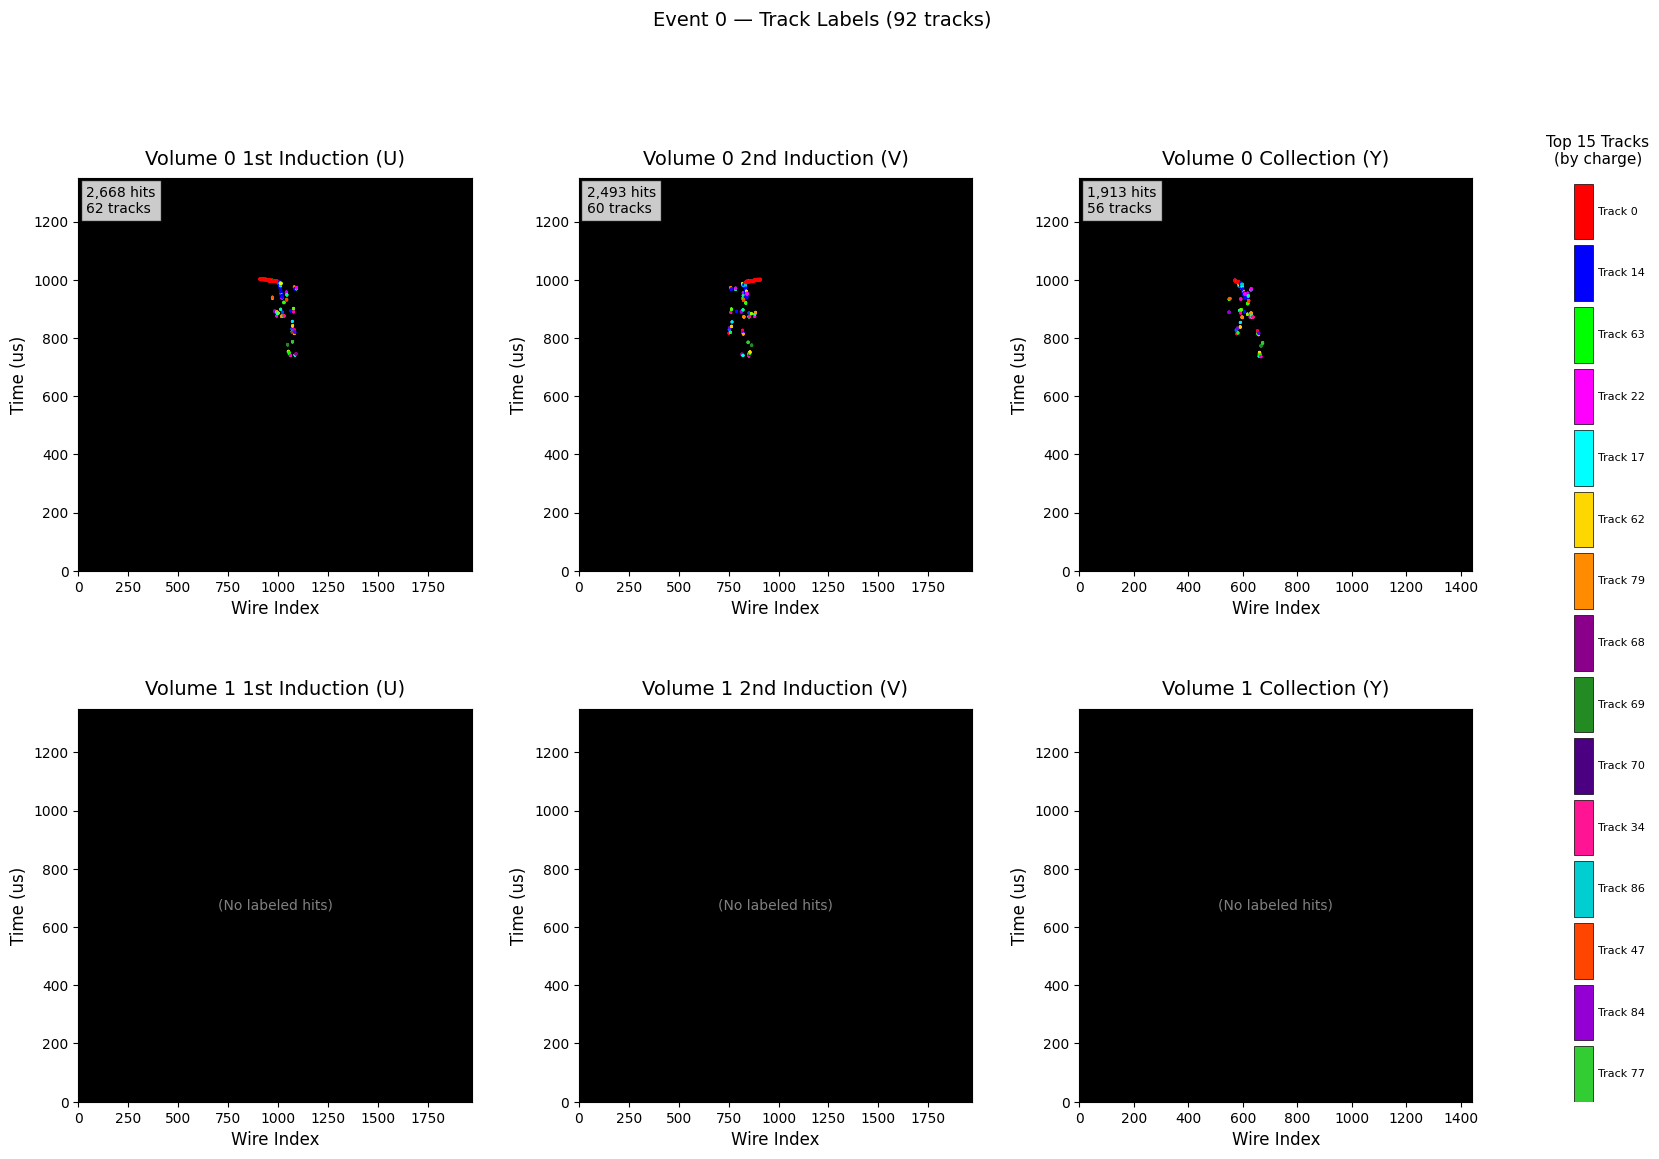

In [ ]:
# =============================================================================
# VISUALIZE TRACK LABELS
# =============================================================================

if INCLUDE_TRACK_HITS:
    top_tracks = get_top_tracks_by_charge(track_hits, top_n=20)

    # Count unique tracks across all volumes
    all_tids = np.concatenate([
        np.asarray(deposits.volumes[v].track_ids[:deposits.volumes[v].n_actual])
        for v in range(n_volumes)
    ])
    n_unique_tracks = len(np.unique(all_tids))

    if top_tracks:
        print("Top 10 tracks by charge:")
        for i, (tid, charge) in enumerate(top_tracks[:10]):
            print(f"  {i+1:2d}. Track {tid:4d}: {charge:12,.1f}")

    fig_tracks = visualize_track_labels(track_hits, cfg, top_tracks, max_tracks=15)
    fig_tracks.suptitle(f'Event {EVENT_IDX} — Track Labels ({n_unique_tracks:,} tracks)',
                        fontsize=14, y=1.02)
    fig_tracks.savefig("plots/track_labels_new.png", dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
else:
    print("Track labeling disabled.")

In [34]:
# =============================================================================
# PLOTLY: TRACK LABELS (INTERACTIVE)
# =============================================================================
if INCLUDE_TRACK_HITS:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

    _DISTINCT = [
        '#FF4444','#4488FF','#44FF44','#FF44FF','#44FFFF',
        '#FFD700','#FF8C00','#CC66CC','#33AA33','#8866FF',
        '#FF6699','#00CED1','#FF6633','#AA33FF','#66FF33',
        '#AA6633','#33BBAA','#FF99CC','#6699FF','#CC2244',
    ]

    _top_tids = [tid for tid, _ in top_tracks[:len(_DISTINCT)]]
    _tid_to_color = {tid: _DISTINCT[i] for i, tid in enumerate(_top_tids)}

    _n_rows = cfg.n_volumes
    _n_cols = max(cfg.volumes[v].n_planes for v in range(cfg.n_volumes))
    _titles = [
        f"Vol {vi} — {cfg.plane_names[vi][pi]}-plane"
        for vi in range(_n_rows)
        for pi in range(cfg.volumes[vi].n_planes)
    ]

    fig_labels_px = make_subplots(
        rows=_n_rows, cols=_n_cols,
        subplot_titles=_titles,
        horizontal_spacing=0.08, vertical_spacing=0.12,
    )

    _added_tids = set()
    for vi in range(_n_rows):
        for pi in range(cfg.volumes[vi].n_planes):
            data = track_hits.get((vi, pi), {})
            nl = int(data.get('num_labeled', 0))
            if nl == 0:
                continue
            _labeled = np.array(data['labeled_hits'][:nl])
            _tids    = np.array(data['labeled_track_ids'][:nl])

            for _tid in np.unique(_tids):
                _mask = _tids == _tid
                _color = _tid_to_color.get(int(_tid), '#888888')
                _show  = int(_tid) not in _added_tids
                _added_tids.add(int(_tid))

                fig_labels_px.add_trace(go.Scattergl(
                    x=_labeled[_mask, 1].astype(float) * cfg.time_step_us,
                    y=_labeled[_mask, 0].astype(float),
                    mode='markers',
                    marker=dict(color=_color, size=2),
                    name=f"Track {_tid}",
                    legendgroup=f"track_{_tid}",
                    showlegend=_show,
                    hovertemplate=f"Track {_tid}<br>time: %{{x:.2f}} µs<br>wire: %{{y}}<extra></extra>",
                ), row=vi + 1, col=pi + 1)

            fig_labels_px.update_xaxes(title_text="Time (µs)", row=vi + 1, col=pi + 1)
            fig_labels_px.update_yaxes(title_text="Wire",       row=vi + 1, col=pi + 1)

    fig_labels_px.update_layout(
        title=f"Track Labels — Event {EVENT_IDX}  ({n_unique_tracks:,} unique tracks)",
        height=400 * _n_rows, width=420 * _n_cols,
        plot_bgcolor='#111111', paper_bgcolor='white',
        font=dict(size=11),
    )
    fig_labels_px.show()
else:
    print("Track labeling disabled.")


Rank 2: Track 14, charge=1,457,897.6
Track 14: 1,269 labeled hits


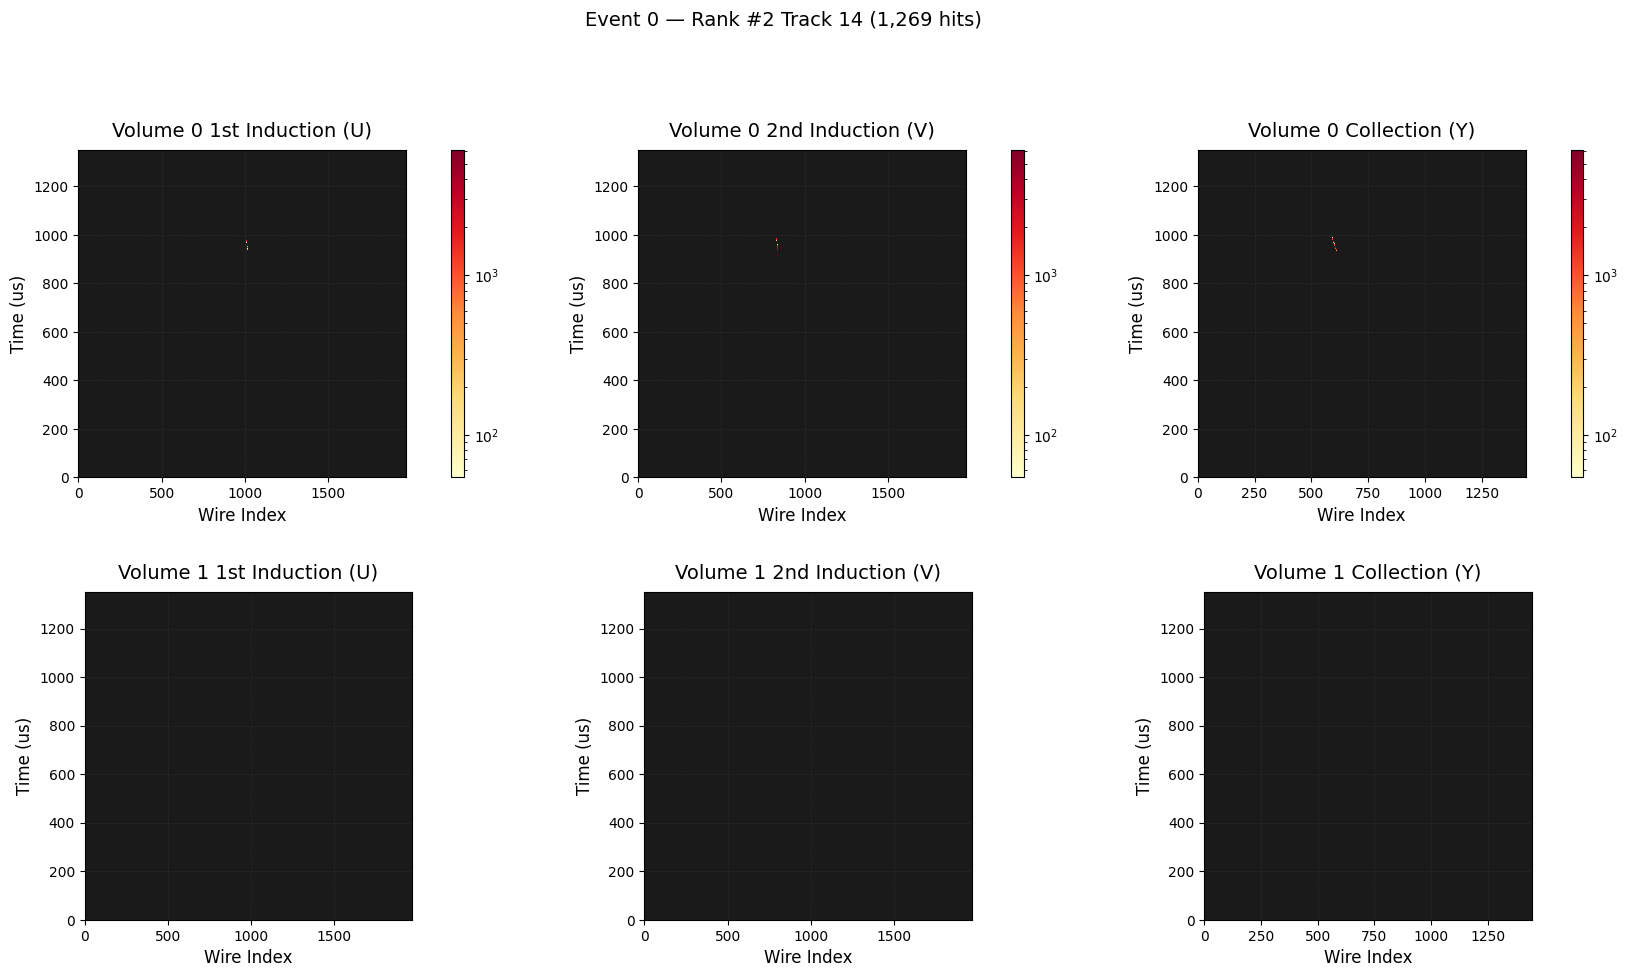

In [35]:
# =============================================================================
# SINGLE TRACK VISUALIZATION (SPARSE)
# =============================================================================

TRACK_RANK = 2  # Nth most active track (1-indexed)

if INCLUDE_TRACK_HITS and top_tracks and TRACK_RANK <= len(top_tracks):
    selected_tid, selected_charge = top_tracks[TRACK_RANK - 1]
    print(f"Rank {TRACK_RANK}: Track {selected_tid}, charge={selected_charge:,.1f}")

    single_sparse = {}
    total_track_hits = 0

    for (vi, pi), data in track_hits.items():
        nl = int(data['num_labeled'])
        if nl > 0:
            labeled = np.array(data['labeled_hits'][:nl])
            tids = np.array(data['labeled_track_ids'][:nl])
            mask = tids == selected_tid

            if mask.any():
                single_sparse[(vi, pi)] = {
                    'wire': labeled[mask, 0].astype(np.int32),
                    'time': labeled[mask, 1].astype(np.int32),
                    'values': labeled[mask, 2].astype(np.float32),
                }
                total_track_hits += int(mask.sum())
            else:
                single_sparse[(vi, pi)] = {
                    'wire': np.array([], dtype=np.int32),
                    'time': np.array([], dtype=np.int32),
                    'values': np.array([], dtype=np.float32),
                }
        else:
            single_sparse[(vi, pi)] = {
                'wire': np.array([], dtype=np.int32),
                'time': np.array([], dtype=np.int32),
                'values': np.array([], dtype=np.float32),
            }

    print(f"Track {selected_tid}: {total_track_hits:,} labeled hits")

    fig_single = visualize_diffused_charge(single_sparse, cfg,
                                            log_norm=True, threshold=50,
                                            sparse=True)
    fig_single.suptitle(
        f'Event {EVENT_IDX} — Rank #{TRACK_RANK} Track {selected_tid} ({total_track_hits:,} hits)',
        fontsize=14, y=1.02)
    fig_single.savefig("plots/single_track_new.png", dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
else:
    print("Track labeling disabled or rank not available.")

In [36]:
# =============================================================================
# PLOTLY: SINGLE TRACK (INTERACTIVE)
# =============================================================================
if INCLUDE_TRACK_HITS and top_tracks and TRACK_RANK <= len(top_tracks):
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

    _n_rows = cfg.n_volumes
    _n_cols = max(cfg.volumes[v].n_planes for v in range(cfg.n_volumes))
    _titles = [
        f"Vol {vi} — {cfg.plane_names[vi][pi]}-plane"
        for vi in range(_n_rows)
        for pi in range(cfg.volumes[vi].n_planes)
    ]

    fig_single_px = make_subplots(
        rows=_n_rows, cols=_n_cols,
        subplot_titles=_titles,
        horizontal_spacing=0.08, vertical_spacing=0.12,
    )

    for _idx, ((vi, pi), data) in enumerate(sorted(single_sparse.items())):
        _wire = np.asarray(data['wire'],   dtype=np.float32)
        _t    = np.asarray(data['time'],   dtype=np.float32) * cfg.time_step_us
        _vals = np.asarray(data['values'], dtype=np.float32)
        _show_scale = (_idx == 0)

        if len(_wire) > 0:
            _log_vals = np.log10(np.clip(_vals, 1, None))
        else:
            _log_vals = _vals

        fig_single_px.add_trace(go.Scattergl(
            x=_t, y=_wire,
            mode='markers',
            marker=dict(
                color=_log_vals,
                colorscale='Cividis',
                size=3,
                showscale=_show_scale,
                colorbar=dict(title='log₁₀(charge)', thickness=12) if _show_scale else None,
            ),
            name=f"Vol{vi}/{cfg.plane_names[vi][pi]}",
            hovertemplate="time: %{x:.2f} µs<br>wire: %{y}<br>charge: %{marker.color:.2f}<extra></extra>",
        ), row=vi + 1, col=pi + 1)

        fig_single_px.update_xaxes(title_text="Time (µs)", row=vi + 1, col=pi + 1)
        fig_single_px.update_yaxes(title_text="Wire",       row=vi + 1, col=pi + 1)

    fig_single_px.update_layout(
        title=f"Event {EVENT_IDX} — Rank #{TRACK_RANK} Track {selected_tid}  ({total_track_hits:,} hits)",
        height=400 * _n_rows, width=420 * _n_cols,
        plot_bgcolor='#111111', paper_bgcolor='white',
        font=dict(size=11),
        showlegend=False,
    )
    fig_single_px.show()
else:
    print("Track labeling disabled or rank not available.")


## Summary

In [37]:
# =============================================================================
# SUMMARY
# =============================================================================

print("=" * 60)
print(" SIMULATION SUMMARY")
print("=" * 60)

print(f"\nInput:")
print(f"  Data: {DATA_PATH}, Event: {EVENT_IDX}")
print(f"  Total deposits: {n_total:,}")
for v in range(n_volumes):
    print(f"  Volume {v}: {deposits.volumes[v].n_actual:,}")

print(f"\nSimulation:")
print(f"  Time: {elapsed:.2f}s")
print(f"  Throughput: {n_total / elapsed:,.0f} seg/s")
print(f"  Output format: {cfg.output_format}")

if INCLUDE_TRACK_HITS:
    print(f"\nTrack hits: {total_hits:,}")

total_pix = sum(len(d['values']) for d in sparse_signals.values())
total_dense_pix = sum(cfg.volumes[v].num_wires[p] * cfg.num_time_steps
                      for v in range(cfg.n_volumes)
                      for p in range(cfg.volumes[v].n_planes))
print(f"\nSparse output ({THRESHOLD_ENC} e-):")
print(f"  Pixels: {total_pix:,}")
print(f"  Sparsity: {(1 - total_pix/total_dense_pix)*100:.1f}%")

print(f"\nSettings:")
print(f"  Noise: {'ON' if INCLUDE_NOISE else 'OFF'}")
print(f"  Electronics: {'ON' if INCLUDE_ELECTRONICS else 'OFF'}")
print(f"  Digitization: {'ON' if INCLUDE_DIGITIZATION else 'OFF'}")
print(f"  SCE: {'ON' if INCLUDE_ELECTRIC_DISTORTIONS else 'OFF'}")
print(f"  Track labeling: {'ON' if INCLUDE_TRACK_HITS else 'OFF'}")

 SIMULATION SUMMARY

Input:
  Data: muon.h5, Event: 0
  Total deposits: 5,335
  Volume 0: 5,335
  Volume 1: 0

Simulation:
  Time: 8.20s
  Throughput: 651 seg/s
  Output format: bucketed

Track hits: 9,656

Sparse output (1200 e-):
  Pixels: 12,108
  Sparsity: 100.0%

Settings:
  Noise: OFF
  Electronics: OFF
  Digitization: ON
  SCE: OFF
  Track labeling: ON


=== Primary Particle ===
  Species:        μ⁻ (PDG 13)
  Kinetic energy: 176.44 MeV
  Rest mass:      105.6584 MeV/c²
  Total energy:   282.10 MeV
  Momentum (px,py,pz): (0.0009, 176.4418, 0.0005) MeV/c
  Vertex: x=-550.0 mm, y=0.00 mm, z=-450.0 mm, t=5.0 ns
=== Secondaries (91 particles) ===
  e⁻     (PDG    11):   73
  γ      (PDG    22):   17
  e⁺     (PDG   -11):    1
  μ⁻     (PDG    13):    1


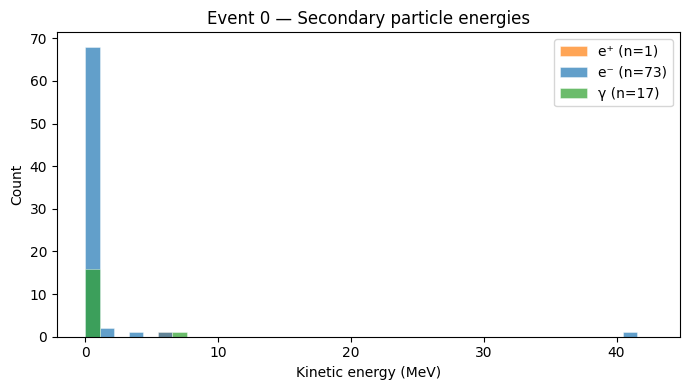

In [38]:
# =============================================================================
# GROUND TRUTH PARTICLES
# =============================================================================

import h5py
import numpy as np
import matplotlib.pyplot as plt

PDG_NAMES = {13: 'μ⁻', -13: 'μ⁺', 11: 'e⁻', -11: 'e⁺', 22: 'γ',
             2212: 'p', 2112: 'n', 211: 'π⁺', -211: 'π⁻', 111: 'π⁰'}
PDG_COLORS = {11: 'tab:blue', -11: 'tab:orange', 22: 'tab:green'}

with h5py.File(DATA_PATH, 'r') as f:
    primaries = f['primary/geant4'][EVENT_IDX]
    particles = f['particle/geant4'][EVENT_IDX]
    vtx       = f['vertex/geant4'][EVENT_IDX]

muon = primaries[0]
total_energy = float(muon['ke']) + float(muon['mass'])

print("=== Primary Particle ===")
print(f"  Species:        {PDG_NAMES.get(int(muon['pdg']), str(int(muon['pdg'])))} (PDG {int(muon['pdg'])})")
print(f"  Kinetic energy: {muon['ke']:.2f} MeV")
print(f"  Rest mass:      {muon['mass']:.4f} MeV/c²")
print(f"  Total energy:   {total_energy:.2f} MeV")
print(f"  Momentum (px,py,pz): ({muon['px']:.4f}, {muon['py']:.4f}, {muon['pz']:.4f}) MeV/c")
print(f"  Vertex: x={vtx[0]['x']:.1f} mm, y={vtx[0]['y']:.2f} mm, z={vtx[0]['z']:.1f} mm, t={vtx[0]['t']:.1f} ns")

secondaries = particles[particles['parent_track_id'] != -1]
print(f"=== Secondaries ({len(secondaries)} particles) ===")
pdgs = particles['pdg']
unique, counts = np.unique(pdgs, return_counts=True)
for pdg, count in sorted(zip(unique.tolist(), counts.tolist()), key=lambda x: -x[1]):
    name = PDG_NAMES.get(pdg, str(pdg))
    print(f"  {name:<6} (PDG {pdg:>5}): {count:>4}")

# --- Histogram of secondary kinetic energies by species ---
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, secondaries['ke'].max() * 1.05, 40)

for pdg in np.unique(secondaries['pdg']):
    mask = secondaries['pdg'] == pdg
    ke_vals = secondaries['ke'][mask]
    name = PDG_NAMES.get(int(pdg), str(int(pdg)))
    color = PDG_COLORS.get(int(pdg), 'tab:gray')
    ax.hist(ke_vals, bins=bins, label=f"{name} (n={mask.sum()})",
            color=color, alpha=0.7, edgecolor='white', linewidth=0.4)

ax.set_xlabel("Kinetic energy (MeV)")
ax.set_ylabel("Count")
ax.set_title(f"Event {EVENT_IDX} — Secondary particle energies")
ax.legend()
fig.tight_layout()
fig.savefig("plots/secondary_energies.png", dpi=150, bbox_inches='tight')
plt.show()

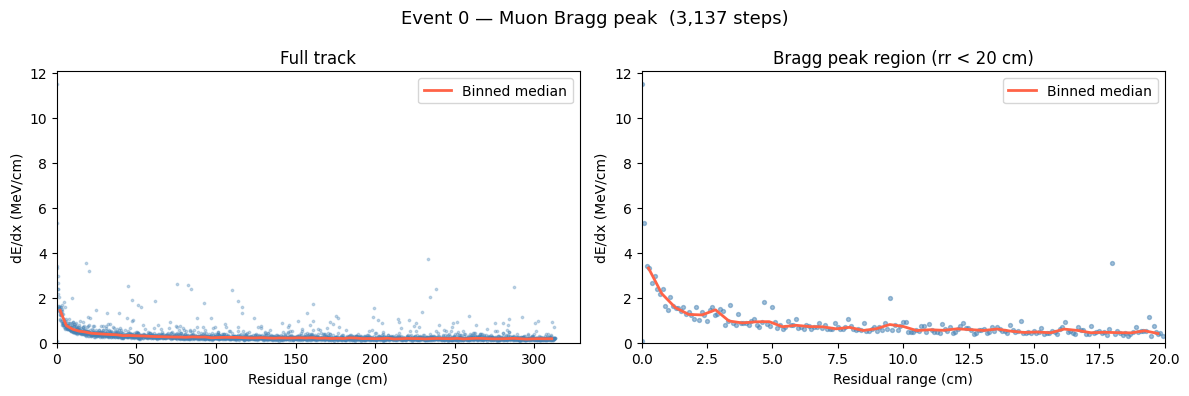

Total muon path length: 313.1 cm
dE/dx MIP (rr > 50 cm):    0.209 MeV/cm
dE/dx Bragg peak (rr<2cm): 1.640 MeV/cm


In [39]:
# =============================================================================
# BRAGG PEAK: dE/dx vs RESIDUAL RANGE (muon only)
# =============================================================================

import h5py
import numpy as np
import matplotlib.pyplot as plt

with h5py.File(DATA_PATH, 'r') as f:
    steps = f['pstep/lar_vol'][EVENT_IDX]

muon_mask = (steps['track_id'] == 0) & (steps['dx'] > 0) & (steps['de'] > 0)
mu = steps[muon_mask]

x  = np.array(mu['x'], dtype=np.float64)
y  = np.array(mu['y'], dtype=np.float64)
z  = np.array(mu['z'], dtype=np.float64)
de = np.array(mu['de'], dtype=np.float64)
dx = np.array(mu['dx'], dtype=np.float64)

order = np.argsort(y)
x, y, z, de, dx = x[order], y[order], z[order], de[order], dx[order]

path = np.sqrt(np.diff(x, prepend=x[0])**2 +
               np.diff(y, prepend=y[0])**2 +
               np.diff(z, prepend=z[0])**2)
path[0] = dx[0]
total_path = path.sum()
residual_range = total_path - np.cumsum(path)
dedx = de / dx

def binned_median(rr, vals, bins):
    idx = np.digitize(rr, bins) - 1
    cen, med = [], []
    for b in range(len(bins) - 1):
        sel = vals[idx == b]
        if len(sel) >= 2:
            med.append(np.median(sel))
            cen.append(0.5 * (bins[b] + bins[b+1]))
    return np.array(cen), np.array(med)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

# ── Left: full track ──────────────────────────────────────────────────────
ax1.scatter(residual_range, dedx, s=3, alpha=0.3, color='steelblue', zorder=2)
cen, med = binned_median(residual_range, dedx, np.linspace(0, residual_range.max(), 80))
ax1.plot(cen, med, color='tomato', lw=2)
ax1.set_xlabel('Residual range (cm)')
ax1.set_ylabel('dE/dx (MeV/cm)')
ax1.set_title('Full track')
ax1.set_xlim(left=0); ax1.set_ylim(bottom=0)

# ── Middle: last 20 cm ────────────────────────────────────────────────────
zoom1 = residual_range < 20
ax2.scatter(residual_range[zoom1], dedx[zoom1], s=8, alpha=0.5, color='steelblue', zorder=2)
cen2, med2 = binned_median(residual_range[zoom1], dedx[zoom1], np.linspace(0, 20, 40))
ax2.plot(cen2, med2, color='tomato', lw=2)
ax2.set_xlabel('Residual range (cm)')
ax2.set_ylabel('dE/dx (MeV/cm)')
ax2.set_title('Last 20 cm')
ax2.set_xlim(0, 20); ax2.set_ylim(bottom=0)

# ── Right: last 2 cm — peak + fall ────────────────────────────────────────
zoom2 = residual_range < 2
ax3.scatter(residual_range[zoom2], dedx[zoom2], s=20, alpha=0.7, color='steelblue',
            zorder=2, label='GEANT4 steps')
# No binning here — plot every step individually
ax3.set_xlabel('Residual range (cm)')
ax3.set_ylabel('dE/dx (MeV/cm)')
ax3.set_title('Bragg peak (rr < 2 cm)')
ax3.set_xlim(0, 2); ax3.set_ylim(bottom=0)
ax3.legend()

fig.suptitle(f'Event {EVENT_IDX} — Muon Bragg peak  ({len(dedx):,} steps)', fontsize=13)
fig.tight_layout()
fig.savefig('plots/bragg_peak.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total muon path length: {total_path:.1f} cm')
print(f'dE/dx MIP (rr > 50 cm):    {np.median(dedx[residual_range > 50]):.3f} MeV/cm')
print(f'dE/dx Bragg peak (rr<0.1): {np.max(dedx[residual_range < 0.1]):.3f} MeV/cm')
print()
print('Last 5 steps (closest to stopping point):')
for rr, d in sorted(zip(residual_range, dedx))[:5]:
    print(f'  rr={rr:.4f} cm  dE/dx={d:.3f} MeV/cm')


In [40]:
# =============================================================================
# 3D PLOTLY: EDEP-SIM DEPOSITS
# Colored by (1) deposit energy or (2) GT particle species
# =============================================================================

import h5py
import numpy as np
import plotly.graph_objects as go

PDG_NAMES  = {13: 'μ⁻', -13: 'μ⁺', 11: 'e⁻', -11: 'e⁺', 22: 'γ',
              2212: 'p', 2112: 'n', 2147483647: 'sentinel'}
PDG_COLORS = {13: '#FF4444', -13: '#FF8888', 11: '#4488FF',
              -11: '#FF9900', 22: '#44DD44'}

with h5py.File(DATA_PATH, 'r') as f:
    steps = f['pstep/lar_vol'][EVENT_IDX]

x   = np.array(steps['x'],        dtype=np.float32)
y   = np.array(steps['y'],        dtype=np.float32)
z   = np.array(steps['z'],        dtype=np.float32)
de  = np.array(steps['de'],       dtype=np.float32)
pdg = np.array(steps['pdg'],      dtype=np.int32)
tid = np.array(steps['track_id'], dtype=np.int32)

valid = (pdg != 2147483647) & (de > 0)
x, y, z, de, pdg, tid = x[valid], y[valid], z[valid], de[valid], pdg[valid], tid[valid]

log_de    = np.log10(np.clip(de, 1e-6, None))
pdg_label = [PDG_NAMES.get(int(p), str(int(p))) for p in pdg]
hover     = [f'PDG: {n}<br>track: {t}<br>dE: {e:.4f} MeV<br>({xi:.0f}, {yi:.0f}, {zi:.0f}) mm'
             for n, t, e, xi, yi, zi in zip(pdg_label, tid, de, x, y, z)]

# ── 1: colored by deposit energy ──────────────────────────────────────────
fig_energy = go.Figure(go.Scatter3d(
    x=x, y=y, z=z,
    mode='markers',
    marker=dict(
        size=2, color=log_de, colorscale='Plasma', opacity=0.8,
        colorbar=dict(title='log₁₀(dE / MeV)', thickness=14),
    ),
    text=hover,
    hovertemplate='%{text}<extra></extra>',
))
fig_energy.update_layout(
    title=f'Event {EVENT_IDX} — Deposits colored by energy ({len(x):,} steps)',
    scene=dict(xaxis_title='x (mm)', yaxis_title='y (mm)', zaxis_title='z (mm)',
               bgcolor='#111111'),
    paper_bgcolor='white', height=650,
)
fig_energy.show()

# ── 2: colored by particle species ────────────────────────────────────────
fig_species = go.Figure()
for p in np.unique(pdg):
    mask  = pdg == p
    name  = PDG_NAMES.get(int(p), f'PDG {p}')
    color = PDG_COLORS.get(int(p), '#AAAAAA')
    fig_species.add_trace(go.Scatter3d(
        x=x[mask], y=y[mask], z=z[mask],
        mode='markers',
        marker=dict(size=2, color=color, opacity=0.8),
        name=f'{name} ({mask.sum():,})',
        text=[hover[i] for i in np.where(mask)[0]],
        hovertemplate='%{text}<extra></extra>',
    ))
fig_species.update_layout(
    title=f'Event {EVENT_IDX} — Deposits colored by particle species',
    scene=dict(xaxis_title='x (mm)', yaxis_title='y (mm)', zaxis_title='z (mm)',
               bgcolor='#111111'),
    paper_bgcolor='white', height=650,
)
fig_species.show()
